In [1]:
# world3_population.py
# Reproduces the World3 Population Sector (one-level population) equations
# Source: Meadows et al., Dynamics of Growth in a Finite World (1974), Ch. 2 (Population Sector)

from __future__ import annotations
from dataclasses import dataclass, field
from typing import Callable, Dict, List, Tuple, Union
import numpy as np

# -----------------------------
# Utility functions (DYNAMO-like)
# -----------------------------

def lerp(x0: float, y0: float, x1: float, y1: float, x: float) -> float:
    if x1 == x0:
        return y0
    t = (x - x0) / (x1 - x0)
    return y0 + t * (y1 - y0)

def tabhl(points: List[Tuple[float, float]], x: float) -> float:
    """Piecewise-linear table lookup. points must be sorted by x ascending."""
    if x <= points[0][0]:
        return points[0][1]
    if x >= points[-1][0]:
        return points[-1][1]
    for i in range(1, len(points)):
        x0, y0 = points[i-1]
        x1, y1 = points[i]
        if x <= x1:
            return lerp(x0, y0, x1, y1, x)
    return points[-1][1]

def smooth_first_order(prev_y: float, x: float, tau: float, dt: float) -> float:
    """First-order exponential smoothing (information delay)."""
    if tau <= 0:
        return x
    alpha = dt / tau
    if alpha > 1:
        alpha = 1.0
    return prev_y + alpha * (x - prev_y)

def smooth_n(prev_ys: List[float], x: float, tau: float, dt: float) -> List[float]:
    """N-th order exponential delay as cascade of first-order smoothers."""
    if not prev_ys:
        return []
    outs, xin = [], x
    for y in prev_ys:
        y_new = smooth_first_order(y, xin, tau/len(prev_ys), dt)
        outs.append(y_new)
        xin = y_new
    return outs

def clip_switch(before_val: float, after_val: float, t: float, switch_time: float) -> float:
    """CLIP: use before_val if t < switch_time else after_val."""
    return before_val if t < switch_time else after_val


# -----------------------------
# Exogenous driver container
# -----------------------------
@dataclass
class ExogenousSeries:
    value: Union[float, List[float], np.ndarray, Callable[[float], float]]
    def at(self, t_index: int, t: float) -> float:
        v = self.value
        if callable(v): return float(v(t))
        if isinstance(v, (list, np.ndarray)):
            if t_index < 0: return float(v[0])
            if t_index >= len(v): return float(v[-1])
            return float(v[t_index])
        return float(v)


# -----------------------------
# World3 Population (one-level)
# -----------------------------
@dataclass
class World3PopulationOneLevel:
    # Horizon
    t0: int = 1900
    t_end: int = 2100
    dt: float = 1.0

    # State
    POP: float = 1.61e9   # initial population (1900)
    EHSPC: float = 0.0    # effective health services per capita (delayed)
    AIOPC: float = 0.0    # smoothed industrial output per capita (3y)
    DIOPC_filters: List[float] = field(default_factory=lambda: [0.0, 0.0, 0.0])
    PLE_filters: List[float] = field(default_factory=lambda: [28.0, 28.0, 28.0])
    FCFPC_filters: List[float] = field(default_factory=lambda: [0.0, 0.0, 0.0])

    # Exogenous trajectories (user-provided)
    FPC: ExogenousSeries  = field(default_factory=lambda: ExogenousSeries(300.0))   # kg/person-year
    SOPC: ExogenousSeries = field(default_factory=lambda: ExogenousSeries(1000.0))  # $/person-year
    IOPC: ExogenousSeries = field(default_factory=lambda: ExogenousSeries(400.0))   # $/person-year
    PPOLX: ExogenousSeries= field(default_factory=lambda: ExogenousSeries(1.0))     # index (1970=1)

    # Parameters
    LEN: float  = 28.0   # normal preindustrial life expectancy
    SFPC: float = 230.0  # subsistence food per capita
    HSID: float = 20.0   # health services impact delay (y)
    SAD: float  = 20.0   # social adjustment delay (y)
    IEAT: float = 3.0    # income expectation averaging time (y)
    LPD: float  = 20.0   # lifetime perception delay (y)
    DCFSN: float = 4.0   # baseline desired completed family size
    ZPGT: int  = 4000    # (policy switch not active by default)
    FCEST: int = 4000    # (policy switch not active by default)
    PET: int   = 4000
    FFW: float = 0.22    # fraction fertile women
    RLT: float = 30.0    # reproductive lifetime
    MTFN: float = 12.0   # max total fertility baseline (Hutterites)

    # Tables (x, y)
    LMF_table   : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0.0,0.0),(1.0,1.0),(2.0,1.2),(3.0,1.3),(4.0,1.35),(5.0,1.4)
    ])
    HSAPC_table : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,0),(250,20),(500,50),(750,95),(1000,140),(1250,175),(1500,200),(1750,220),(2000,230)
    ])
    LMHS1_table : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,1.0),(20,1.1),(40,1.4),(60,1.6),(80,1.7),(100,1.8)
    ])
    LMHS2_table : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,1.0),(20,1.4),(40,1.6),(60,1.8),(80,1.95),(100,2.0)
    ])
    FPU_table   : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0.0,0.0),(2e9,0.2),(4e9,0.4),(6e9,0.5),(8e9,0.58),(10e9,0.65),(12e9,0.72),(14e9,0.78),(16e9,0.80)
    ])
    CMI_table   : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,0.5),(200,0.05),(400,-0.1),(600,-0.08),(800,-0.02),(1000,0.05),(1200,0.1),(1400,0.15),(1600,0.2)
    ])
    LMP_table   : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,1.0),(10,0.99),(20,0.97),(30,0.95),(40,0.90),(50,0.85),(60,0.75),(70,0.65),(80,0.55),(90,0.40),(100,0.20)
    ])
    SFSN_table  : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,1.25),(200,1.0),(400,0.9),(600,0.8),(800,0.75)
    ])
    FRSN_table  : List[Tuple[float,float]] = field(default_factory=lambda:[
        (-0.2,0.5),(-0.1,0.6),(0.0,0.7),(0.1,0.85),(0.2,1.0)
    ])
    CMPLE_table : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,3.0),(10,2.1),(20,1.6),(30,1.4),(40,1.3),(50,1.2),(60,1.1),(70,1.05),(80,1.0)
    ])
    FM_table    : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,0.0),(10,0.2),(20,0.4),(30,0.6),(40,0.8),(50,0.9),(60,1.0),(70,1.05),(80,1.1)
    ])
    FSAFC_table : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0,0.0),(2,0.005),(4,0.015),(6,0.025),(8,0.03),(10,0.035)
    ])
    FCE_table   : List[Tuple[float,float]] = field(default_factory=lambda:[
        (0.0,0.75),(0.5,0.85),(1.0,0.90),(1.5,0.95),(2.0,0.98),(2.5,0.99),(3.0,1.00)
    ])

    history: Dict[str,List[float]] = field(default_factory=dict)

    # Multipliers
    def LMF(self, FPC_val: float) -> float:
        ratio = FPC_val / self.SFPC if self.SFPC > 0 else 0.0
        return tabhl(self.LMF_table, ratio)
    def LMHS(self, EHSPC_val: float, year: int) -> float:
        pre  = tabhl(self.LMHS1_table, EHSPC_val)
        post = tabhl(self.LMHS2_table, EHSPC_val)
        return clip_switch(pre, post, year, 1940)
    def LMC(self, IOPC_val: float, POP_val: float) -> float:
        fpu = tabhl(self.FPU_table, POP_val)
        cmi = tabhl(self.CMI_table, IOPC_val)
        return 1.0 - (cmi * fpu)
    def LMP(self, PPOLX_val: float) -> float:
        return tabhl(self.LMP_table, PPOLX_val * 10.0)
    def SFSN_fun(self, DIOPC_val: float) -> float:
        return tabhl(self.SFSN_table, DIOPC_val)
    def FRSN_fun(self, FIE_val: float) -> float:
        x = max(min(FIE_val, self.FRSN_table[-1][0]), self.FRSN_table[0][0])
        return tabhl(self.FRSN_table, x)
    def CMPLE_fun(self, PLE_val: float) -> float:
        return tabhl(self.CMPLE_table, PLE_val)
    def FM_fun(self, LE_val: float) -> float:
        return tabhl(self.FM_table, LE_val)
    def FSAFC_fun(self, NFC_val: float) -> float:
        x = max(min(NFC_val, self.FSAFC_table[-1][0]), self.FSAFC_table[0][0])
        return tabhl(self.FSAFC_table, x)
    def FCE_lookup(self, FCFPC_val: float) -> float:
        x = max(min(FCFPC_val, self.FCE_table[-1][0]), self.FCE_table[0][0])
        return tabhl(self.FCE_table, x)

    def run(self) -> Dict[str, List[float]]:
        T = list(range(self.t0, self.t_end+1))
        keys = ["YEAR","POP","B","D","CBR","CDR","LE","LMF","LMHS","LMC","LMP",
                "FPC","SOPC","IOPC","PPOLX","HSAPC","EHSPC","AIOPC","DIOPC",
                "PLE","DTF","DCFS","CMPLE","MTF","FCE","TF","FPU"]
        self.history = {k: [] for k in keys}

        # initialize delayed states
        hsapc0 = tabhl(self.HSAPC_table, self.SOPC.at(0, self.t0))
        self.EHSPC = hsapc0
        self.AIOPC = self.IOPC.at(0, self.t0)
        self.DIOPC_filters = [self.IOPC.at(0, self.t0)]*3
        self.PLE_filters   = [self.LEN]*3
        self.FCFPC_filters = [0.0]*3

        for i, year in enumerate(T):
            FPC_val   = self.FPC.at(i, year)
            SOPC_val  = self.SOPC.at(i, year)
            IOPC_val  = self.IOPC.at(i, year)
            PPOLX_val = self.PPOLX.at(i, year)

            # LE multipliers
            lmf  = self.LMF(FPC_val)
            hsapc = tabhl(self.HSAPC_table, SOPC_val)
            self.EHSPC = smooth_first_order(self.EHSPC, hsapc, self.HSID, self.dt)
            lmhs = self.LMHS(self.EHSPC, year)
            lmc  = self.LMC(IOPC_val, self.POP)
            lmp  = self.LMP(PPOLX_val)
            LE   = self.LEN * lmf * lmhs * lmc * lmp

            # perceived life expectancy
            self.PLE_filters = smooth_n(self.PLE_filters, LE, self.LPD, self.dt)
            PLE = self.PLE_filters[-1]

            # income expectations and delayed IOPC
            self.AIOPC = smooth_first_order(self.AIOPC, IOPC_val, self.IEAT, self.dt)
            FIE = 0.0 if self.AIOPC == 0 else (IOPC_val - self.AIOPC) / self.AIOPC
            self.DIOPC_filters = smooth_n(self.DIOPC_filters, IOPC_val, self.SAD, self.dt)
            DIOPC = self.DIOPC_filters[-1]

            # desired total fertility
            sfsn = self.SFSN_fun(DIOPC)
            frsn = self.FRSN_fun(FIE)
            dcfs_candidate = self.DCFSN * frsn * sfsn
            DCFS = dcfs_candidate if year < self.ZPGT else 2.0
            cmple = self.CMPLE_fun(PLE)
            DTF   = DCFS * cmple

            # maximum total fertility
            fm = self.FM_fun(LE)
            MTF = self.MTFN * fm

            # family planning and FCE
            NFC   = 0.0 if DTF <= 0 else (MTF/DTF) - 1.0
            fsafc = self.FSAFC_fun(NFC)
            FCAPC = fsafc * SOPC_val
            self.FCFPC_filters = smooth_n(self.FCFPC_filters, FCAPC, self.HSID, self.dt)
            FCFPC = self.FCFPC_filters[-1]
            FCE_raw = self.FCE_lookup(FCFPC)
            FCE = FCE_raw if year < self.FCEST else 1.0

            # total fertility and vital rates
            TF = min(MTF, MTF*(1 - FCE) + DTF*FCE)
            B  = TF * self.POP * self.FFW / self.RLT
            D  = self.POP / LE if LE > 0 else self.POP

            # update stock
            self.POP += self.dt * (B - D)

            # record
            self.history["YEAR"].append(year)
            self.history["POP"].append(self.POP)
            self.history["B"].append(B)
            self.history["D"].append(D)
            self.history["CBR"].append(1000.0 * B / self.POP)
            self.history["CDR"].append(1000.0 * D / self.POP)
            self.history["LE"].append(LE)
            self.history["LMF"].append(lmf)
            self.history["LMHS"].append(lmhs)
            self.history["LMC"].append(lmc)
            self.history["LMP"].append(lmp)
            self.history["FPC"].append(FPC_val)
            self.history["SOPC"].append(SOPC_val)
            self.history["IOPC"].append(IOPC_val)
            self.history["PPOLX"].append(PPOLX_val)
            self.history["HSAPC"].append(hsapc)
            self.history["EHSPC"].append(self.EHSPC)
            self.history["AIOPC"].append(self.AIOPC)
            self.history["DIOPC"].append(DIOPC)
            self.history["PLE"].append(PLE)
            self.history["DTF"].append(DTF)
            self.history["DCFS"].append(DCFS)
            self.history["CMPLE"].append(cmple)
            self.history["MTF"].append(MTF)
            self.history["FCE"].append(FCE)
            self.history["TF"].append(TF)
            self.history["FPU"].append(tabhl(self.FPU_table, self.POP))
        return self.history

if __name__ == "__main__":
    years = np.arange(1900, 2101)
    n = len(years)
    # Example exogenous trajectories
    FPC   = np.linspace(260.0, 600.0, n)   # food per capita (kg/py)
    SOPC  = np.linspace(600.0, 1600.0, n)  # services output per cap ($/py)
    IOPC  = np.linspace(200.0, 1200.0, n)  # industrial output per cap ($/py)
    PPOLX = np.linspace(0.5, 4.0, n)       # persistent pollution index (1970=1)

    model = World3PopulationOneLevel(
        FPC=ExogenousSeries(FPC),
        SOPC=ExogenousSeries(SOPC),
        IOPC=ExogenousSeries(IOPC),
        PPOLX=ExogenousSeries(PPOLX),
    )
    hist = model.run()

    import pandas as pd
    pd.DataFrame(hist).to_csv("world3_population_output.csv", index=False)
    print("Saved world3_population_output.csv")

Saved world3_population_output.csv


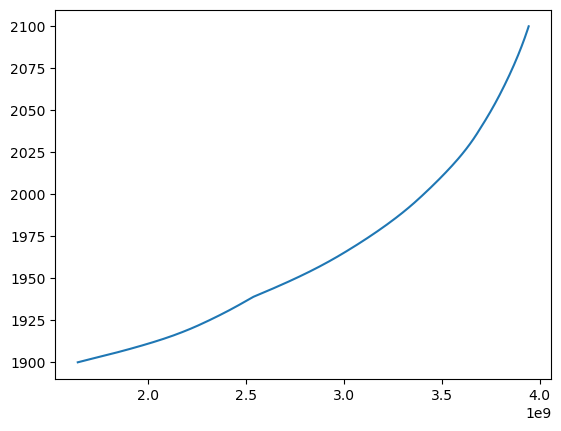

In [6]:
import matplotlib.pyplot as plt
plt.plot(hist['POP'],hist['YEAR'])
plt.show()